# Import The Libraries

In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.43  Python-3.10.14 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
Setup complete  (28 CPUs, 31.8 GB RAM, 210.9/931.5 GB disk)


In [2]:
!nvidia-smi

Wed Apr 29 13:37:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   35C    P8              3W /  160W |     579MiB /   8188MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import glob
from PIL import Image
from IPython.display import display
from glob import glob
import cv2
import random
import os

import warnings
warnings.filterwarnings('ignore')

In [4]:
class Sys:
    EPOCHS = 30
    BATCH_SIZE = 32
    SEED = 6
    LEARNING_RATE = 0.001
    NUM_SAMPLES = 16
    OPTIMIZER = 'Adam'
    ds='dataset/data.yaml'
    samples='dataset/train/images/*'

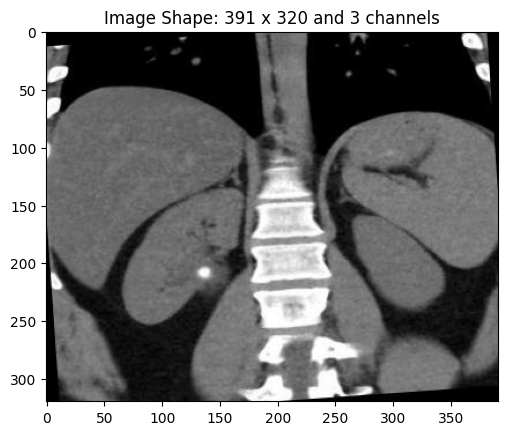

In [5]:
image = cv2.imread('dataset/train/images/1-3-46-670589-33-1-63700700750188529100001-5659992199131706929_png_jpg.rf.32f57db5f742576e560a82af2a4666e7.jpg')
h, w, c = image.shape
plt.imshow(image)
plt.title(f"Image Shape: {w} x {h} and 3 channels")
plt.show()

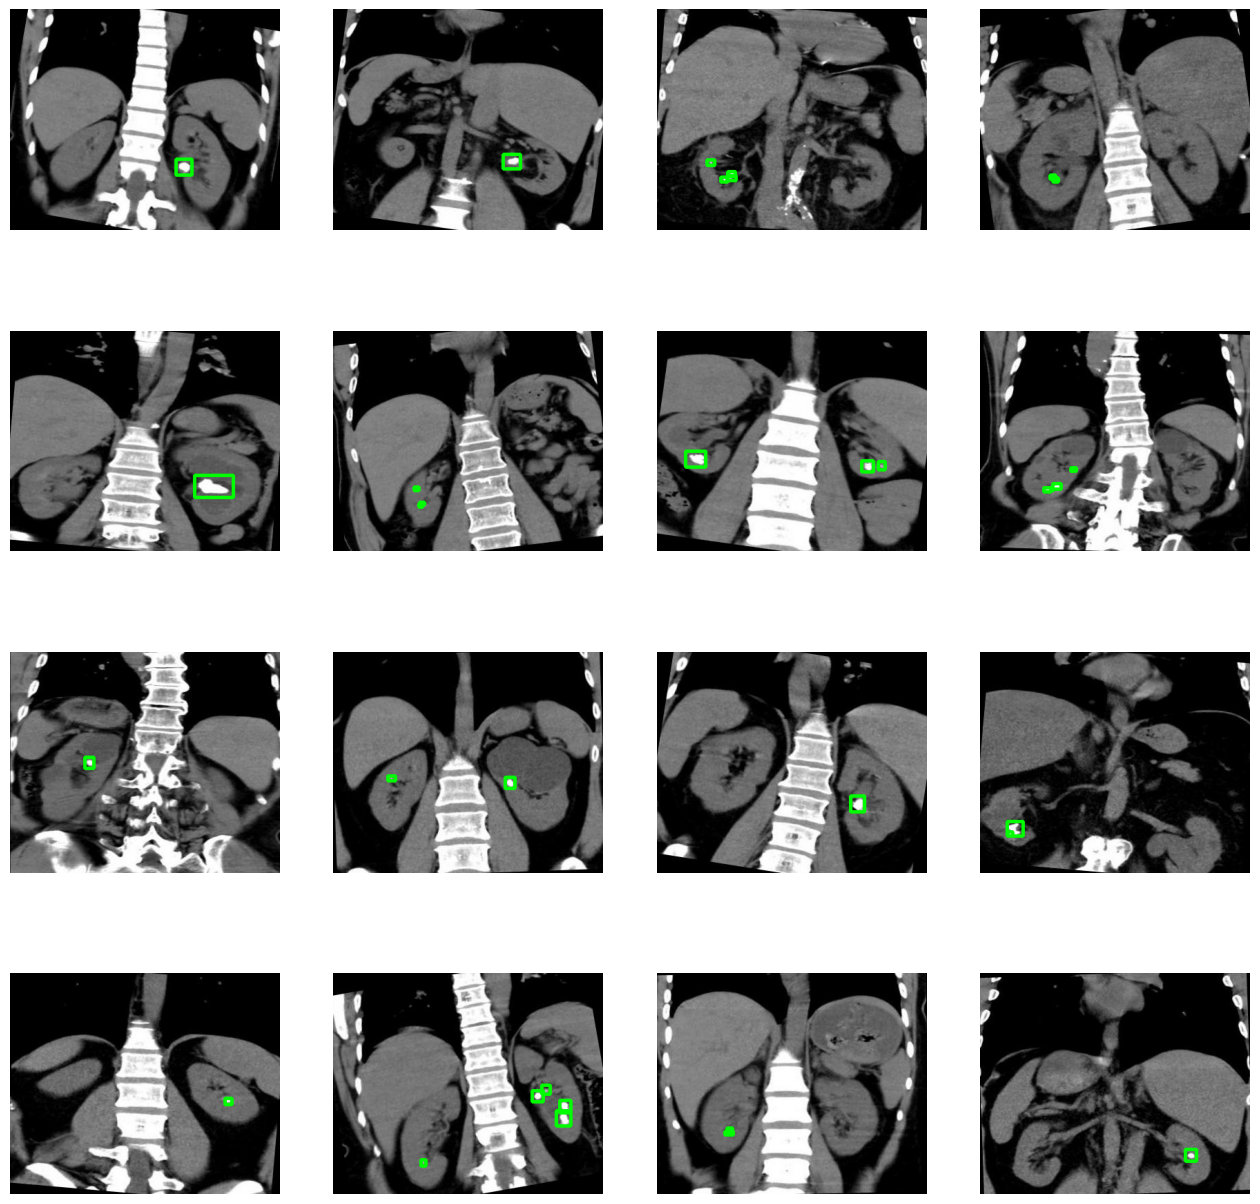

In [6]:
# Define the paths to the images and labels directories
train_images = "dataset/train/images"
train_labels = "dataset/train/labels"

test_images = "dataset/test/images"
test_labels = "dataset/test/labels"

val_images = "dataset/valid/images"
val_labels = "dataset/valid/labels"

# Get a list of all the image files in the training images directory
image_files = os.listdir(train_images)

# Choose 16 random image files from the list
random_images = random.sample(image_files, 16)

# Set up the plot
fig, axs = plt.subplots(4, 4, figsize=(16, 16))

# Loop over the random images and plot the object detections
for i, image_file in enumerate(random_images):
    row = i // 4
    col = i % 4

    # Load the image
    image_path = os.path.join(train_images, image_file)
    image = cv2.imread(image_path)

    # Load the labels for this image
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(train_labels, label_file)
    with open(label_path, "r") as f:
        labels = f.read().strip().split("\n")

    # Loop over the labels and plot the object detections
    # Loop over the labels and plot the object detections
    for label in labels:
        if len(label.split()) != 5:
            continue
        class_id, x_center, y_center, width, height = map(float, label.split())
        x_min = int((x_center - width/2) * image.shape[1])
        y_min = int((y_center - height/2) * image.shape[0])
        x_max = int((x_center + width/2) * image.shape[1])
        y_max = int((y_center + height/2) * image.shape[0])
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)


    # Show the image with the object detections
    axs[row, col].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[row, col].axis('off')

plt.show()

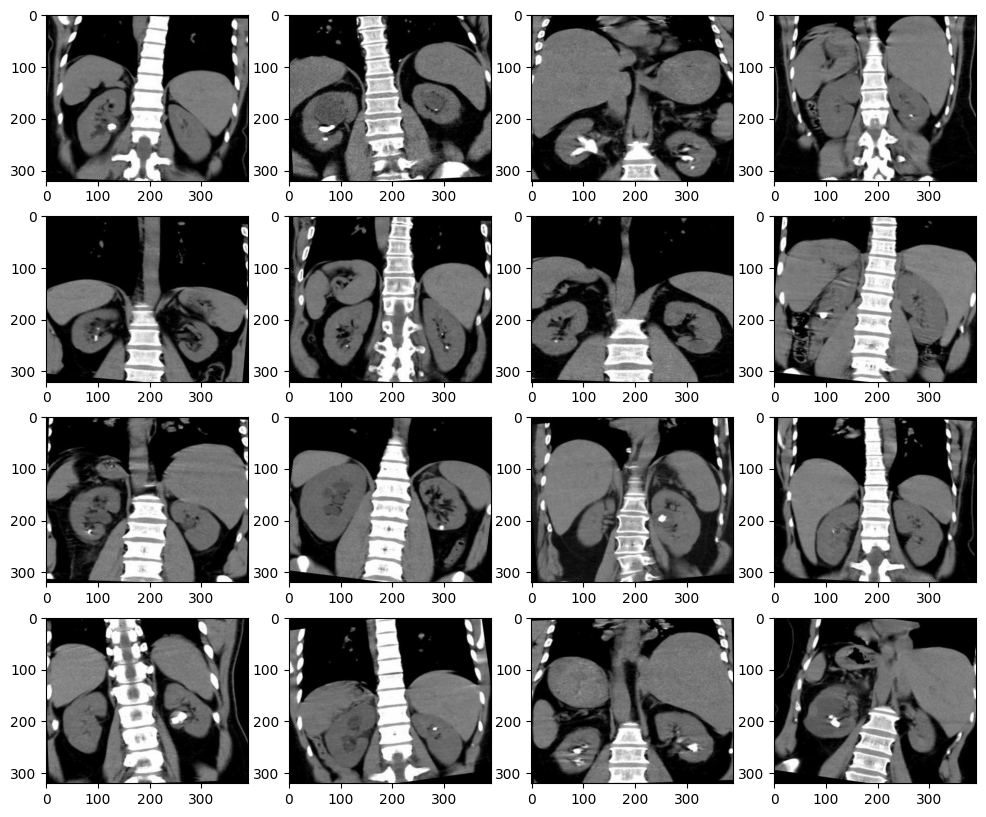

In [7]:
images_for_vis = glob(Sys.samples)
random_image = random.sample(images_for_vis, Sys.NUM_SAMPLES)

plt.figure(figsize=(12,10))
for i in range(Sys.NUM_SAMPLES):
    plt.subplot(4,4,i+1)
    plt.imshow(cv2.imread(random_image[i]))
    plt.axis('on')

# Build & Train The Model

In [8]:
import ultralytics
from ultralytics import YOLO

yolo_v8 = YOLO('yolov8x.pt')

In [9]:
result_predict = yolo_v8.predict(source = image, imgsz=(416))


0: 352x416 (no detections), 37.5ms
Speed: 0.7ms preprocess, 37.5ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 416)


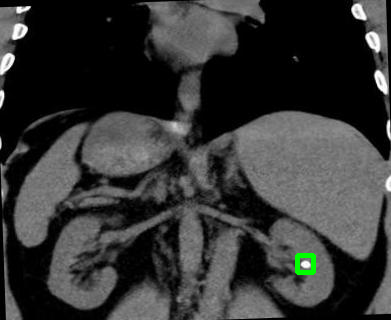

In [10]:
# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

In [11]:
v8_model = yolo_v8.train(data=Sys.ds,seed=Sys.SEED,epochs=Sys.EPOCHS, imgsz=480, patience=10, 
                         lr0=Sys.LEARNING_RATE, optimizer=Sys.OPTIMIZER, dropout=0.2,
                         verbose=True,project='ft_models',name='kidney_stone_yolo_v8')

Ultralytics 8.4.43  Python-3.10.14 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kidney_stone_yolo_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=

# Testing  the model

In [12]:
def stone_detection(img_path, model):
    img = cv2.imread(img_path)
    detect_result = model(img)
    detect_img = detect_result[0].plot()
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
    return detect_img

In [13]:
df = 'dataset/test/images'
df_testing = os.listdir(df)

selected_images = random.sample(df_testing, 16)

In [14]:
model_trained = YOLO('runs/detect/ft_models/kidney_stone_yolo_v8/weights/best.pt')


0: 416x480 2 Stones, 57.1ms
Speed: 0.9ms preprocess, 57.1ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 2 Stones, 42.3ms
Speed: 1.1ms preprocess, 42.3ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 1 Stone, 31.1ms
Speed: 0.9ms preprocess, 31.1ms inference, 2.2ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 1 Stone, 31.1ms
Speed: 1.0ms preprocess, 31.1ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 1 Stone, 31.0ms
Speed: 0.8ms preprocess, 31.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 2 Stones, 31.1ms
Speed: 1.1ms preprocess, 31.1ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 2 Stones, 28.6ms
Speed: 0.9ms preprocess, 28.6ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 480)

0: 416x480 4 Stones, 14.2ms
Speed: 0.8ms preprocess, 14.2ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 

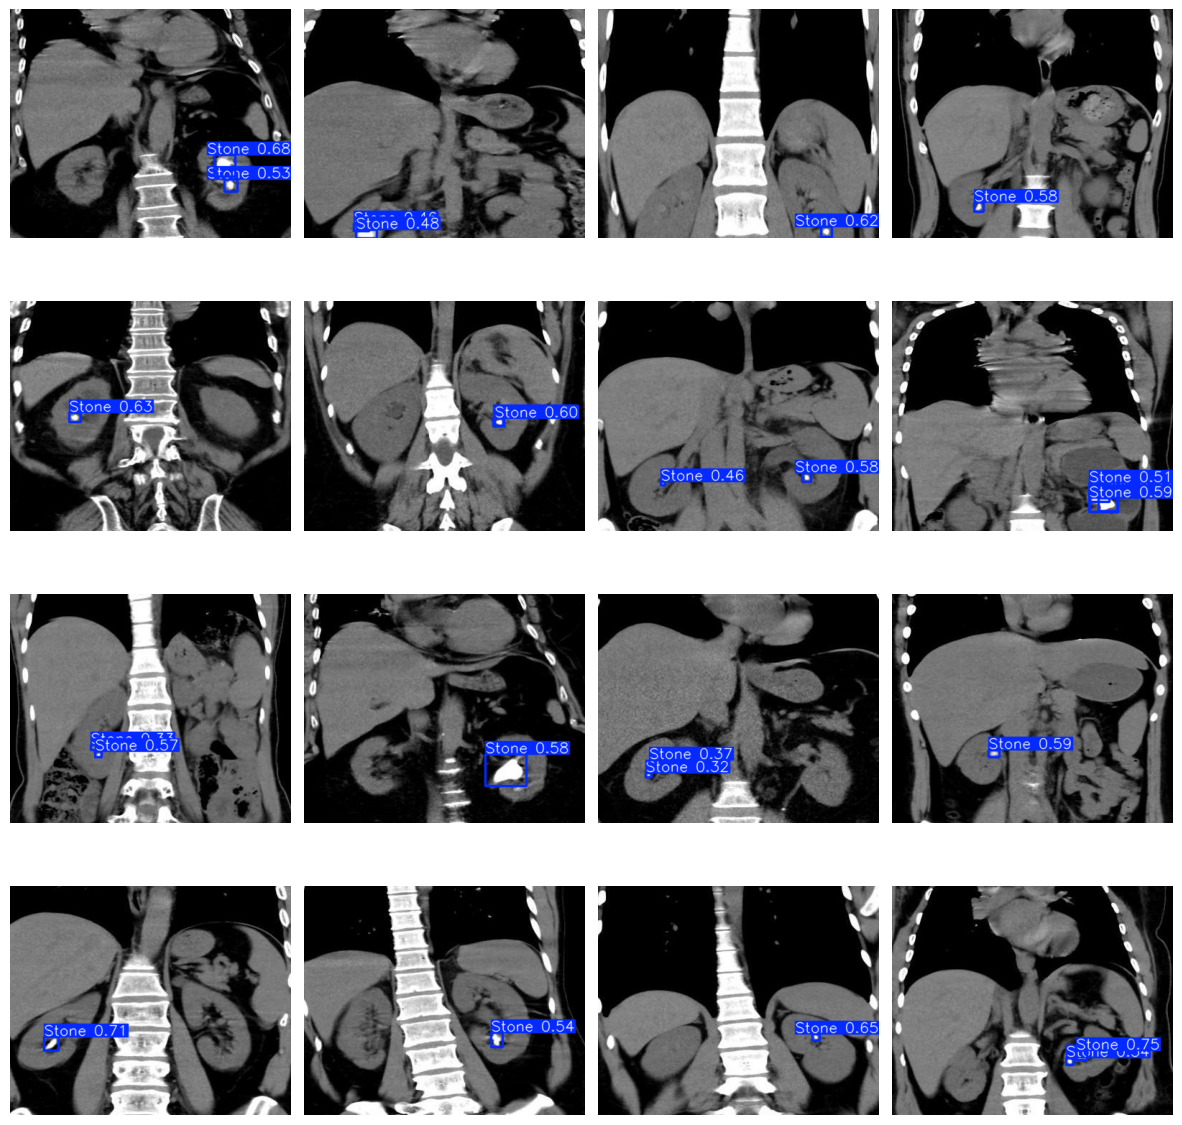

In [15]:
# Create a figure with subplots for each image
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))

for i, img_file in enumerate(selected_images):
    
    # Compute the row and column index of the current subplot
    row_idx = i // 4
    col_idx = i % 4
    
    # Load the current image and run object detection
    img_path = os.path.join(df, img_file)
    detect_img = stone_detection(img_path, model_trained)
    
    # Plot the current image on the appropriate subplot
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis('off')

# Adjust the spacing between the subplots
plt.subplots_adjust(wspace=0.05, hspace=0.05)

In [16]:
results = pd.read_csv('runs/detect/ft_models/kidney_stone_yolo_v8/results.csv')
results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,131.707,2.37697,1.94343,1.30343,0.35040,0.40000,0.26831,0.07895,2.35388,3.37120,1.22837,0.000328,0.000328,0.067500
1,2,262.980,2.12841,1.05551,1.11898,0.75645,0.63077,0.63033,0.24346,2.06289,1.01713,1.08906,0.000640,0.000640,0.034478
2,3,459.614,2.11362,1.05503,1.12422,0.76043,0.62769,0.63666,0.23953,2.06782,1.01655,1.06195,0.000929,0.000929,0.001434
3,4,638.781,2.06448,0.99240,1.09400,0.74652,0.67056,0.63302,0.25272,2.02957,1.02895,1.05299,0.000901,0.000901,0.000901
4,5,763.610,2.11501,0.97646,1.07027,0.67725,0.64000,0.62285,0.22253,2.18414,0.99565,1.09768,0.000868,0.000868,0.000868
5,6,854.983,2.04566,0.97102,1.09733,0.81494,0.67692,0.67602,0.25089,1.99505,0.91712,1.04646,0.000835,0.000835,0.000835
6,7,962.064,2.00960,0.93739,1.09395,0.76427,0.60923,0.67231,0.24075,2.10667,0.98178,1.07059,0.000802,0.000802,0.000802
7,8,1041.660,1.96300,0.91580,1.06705,0.76391,0.69231,0.70002,0.26908,2.01846,0.92972,1.04857,0.000769,0.000769,0.000769
8,9,1289.320,1.99456,0.92634,1.06138,0.78894,0.64408,0.63480,0.23404,2.19297,0.93985,1.10813,0.000736,0.000736,0.000736
9,10,1445.670,1.91736,0.87693,1.05629,0.77447,0.70769,0.68341,0.24903,2.14602,0.93488,1.08619,0.000703,0.000703,0.000703


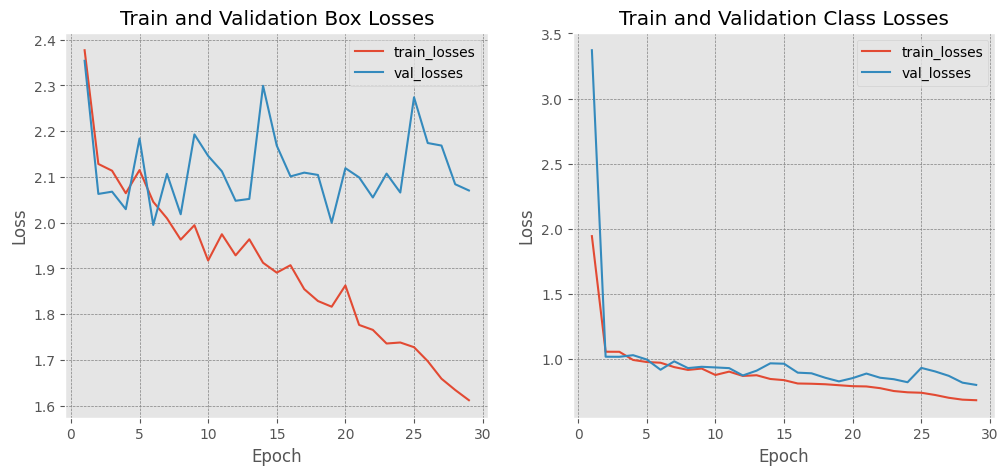

In [17]:
# Remove leading and trailing spaces from column names
results.columns = results.columns.str.strip()

epoch_column = results['epoch']
box_train_losses = results['train/box_loss']
box_val_losses = results['val/box_loss']
cls_train_losses = results['train/cls_loss']
cls_val_losses = results['val/cls_loss']

plt.figure(figsize=(12,5))
plt.style.use('ggplot')  # You can choose a style you prefer
plt.subplot(1,2,1)
plt.plot(epoch_column, box_train_losses, label='train_losses')
plt.plot(epoch_column, box_val_losses, label='val_losses')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')# Add a grid
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Box Losses')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epoch_column, cls_train_losses, label='train_losses')
plt.plot(epoch_column, cls_val_losses, label='val_losses')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')# Add a grid
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Class Losses')
plt.legend()
plt.show()

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

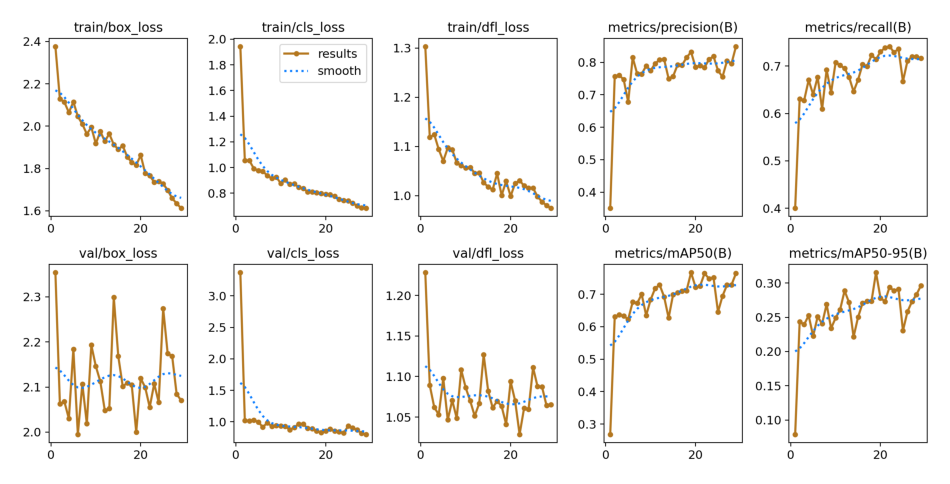

In [18]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.imread('runs/detect/ft_models/kidney_stone_yolo_v8/results.png'))
plt.axis('off')

In [19]:
results.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

(np.float64(-0.5), np.float64(2249.5), np.float64(1499.5), np.float64(-0.5))

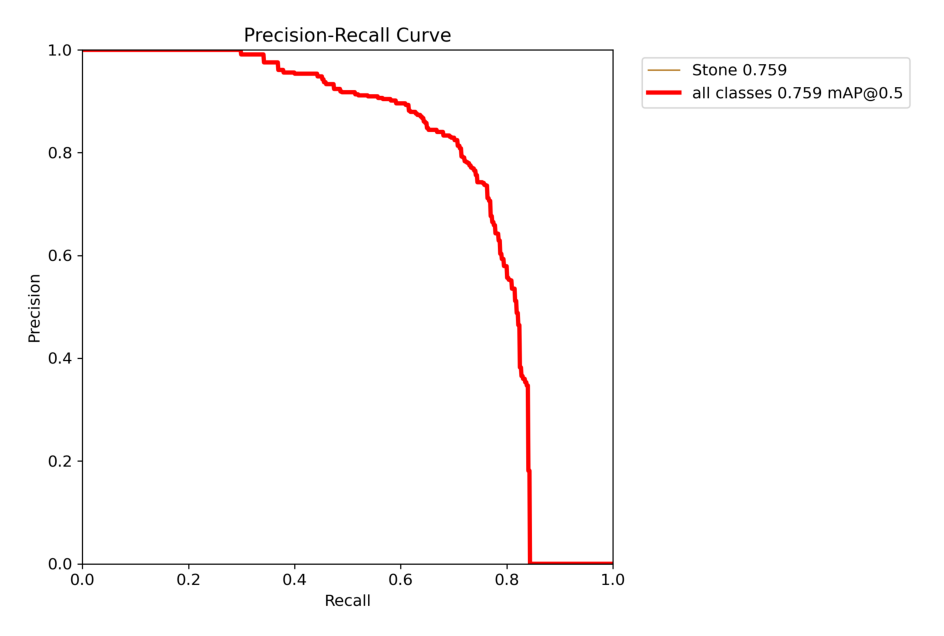

In [20]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.imread('runs/detect/ft_models/kidney_stone_yolo_v8/BoxPR_curve.png'))
plt.axis('off')

In [21]:
single_image='dataset/valid/images/1-3-46-670589-33-1-63737661477473189500001-5463064330587912766_png_jpg.rf.72d5fd49b7ea305b3167bb1d7ac8dbc7.jpg'

In [22]:
y = model_trained.predict(single_image)
print(type(y))


image 1/1 d:\david\tao-healthcare-showcase\kidney_stone\dataset\valid\images\1-3-46-670589-33-1-63737661477473189500001-5463064330587912766_png_jpg.rf.72d5fd49b7ea305b3167bb1d7ac8dbc7.jpg: 416x480 1 Stone, 13.4ms
Speed: 1.0ms preprocess, 13.4ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 480)
<class 'list'>


In [23]:
def show_single_image(img_file, df, model_trained, stone_detection):
    # Load the current image and run object detection
    # img_path = os.path.join(df, img_file)
    detect_img = stone_detection(img_file, model_trained)
    
    # Create a figure and axis for a single image
    fig, ax = plt.subplots(figsize=(5,5))
    
    # Plot the current image
    ax.imshow(detect_img)
    ax.axis('off')  
    
    plt.show()


0: 416x480 1 Stone, 13.0ms
Speed: 0.8ms preprocess, 13.0ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 480)


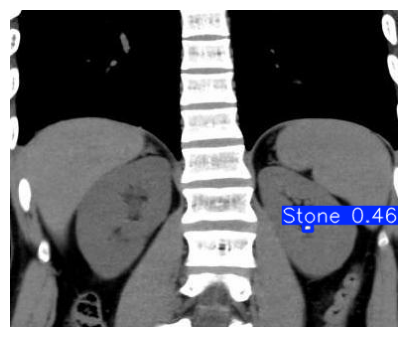

In [24]:
show_single_image(single_image,df,model_trained,stone_detection)

In [25]:
from ultralytics import YOLO
import pandas as pd

# Load your trained YOLO model
model = YOLO('runs/detect/ft_models/kidney_stone_yolo_v8/weights/best.pt')

# Validate on the test set
metrics = model.val(data="dataset/data.yaml", split="test", imgsz=480, batch=32)

# Collect metrics properly
report = {
    "mAP@0.5": metrics.box.map50,
    "mAP@0.5:0.95": metrics.box.map,
    "Precision (mean)": metrics.box.mp,
    "Recall (mean)": metrics.box.mr,
    "F1 (derived)": 2 * (metrics.box.mp * metrics.box.mr) /
                    (metrics.box.mp + metrics.box.mr + 1e-6),
    "Speed (ms/img)": metrics.speed["inference"] + metrics.speed["postprocess"]
}

# Print nicely
df_report = pd.DataFrame(report, index=["YOLOv8 Evaluation"])
print(df_report.T)


Ultralytics 8.4.43  Python-3.10.14 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
Model summary (fused): 113 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 106.828.7 MB/s, size: 17.4 KB)
val: Scanning D:\david\tao-healthcare-showcase\kidney_stone\dataset\test\labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.3s0.9s
                   all        123        224      0.818      0.692      0.711      0.314
Speed: 1.4ms preprocess, 14.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to D:\david\tao-healthcare-showcase\kidney_stone\runs\detect\val
                  YOLOv8 Evaluation
mAP@0.5                    0.711075
mAP@0.5:0.95               0.313880
Precision (mean)           0.818438
Recall (mean)              0.691964
F1 (derived)        

In [26]:
import sys
sys.exit()

SystemExit: 